In [ ]:
import pandas as pd
import os 
import matplotlib.pyplot as plt
import random
from PIL import Image
import requests
from io import BytesIO
from tqdm import tqdm

# Data Preparation

The original Open Images V4 dataset contains millions of images and annotations, which are too large to handle directly. For this project, we selected a subset of 10 animal classes: Dog, Bird, Horse, Cat, Fish, Frog, Bear, Snake, and Sheep. We filtered the original annotation files to include only these classes, ensuring that each class had at least 100 images. The corresponding train, validation, and test files were also filtered so that only images and annotations for these classes were retained. This preprocessing step reduced the dataset to a manageable size while keeping a representative set of images for exploratory data analysis. These steps were completed in DataSetup.py

In [ ]:
filepath_tl = f'.{os.sep}FilteredImages_animalsProject/train-images-with-labels-with-rotation_animalsProject.csv'
train_labels = pd.read_csv(filepath_tl)
filepath_c = f'.{os.sep}FilteredImages_animalsProject/train-annotations-human-imagelabels_animalsProject.csv'
classes = pd.read_csv(filepath_c)

In [ ]:
label_to_animal = {
    "/m/0bt9lr": "Dog",
    "/m/01dws": "Bear",
    "/m/03k3r": "Horse",
    "/m/015p6": "Bird",
    "/m/01yrx": "Cat",
    "/m/09ld4": "Frog",
    "/m/0ch_cf": "Fish",
    "/m/078jl": "Snake",
    "/m/07bgp": "Sheep",
    "/m/07pbfj": "Fish",
    "/m/08hhz2": "Sheep"
}

classes['ClassName'] = classes['LabelName'].map(label_to_animal)

In [ ]:
# merge train_labels with classes to get ClassName
train_labels_merged = train_labels.merge(
    classes[['ImageID', 'ClassName']],  # only keep columns we need
    on='ImageID',
    how='left'
)

In these steps, we loaded the filtered train images and annotation files for our selected animal classes. Using a manually created mapping from label codes to animal names, we added a "ClassName" column to the annotations. Finally, we merged this with the train images dataframe so that each image now has its animal class labeled, which makes it easier to analyze class distributions and sample images in the EDA.

# Preliminary EDA

   Class  Number of Images
0    Dog            159243
1   Bird            152346
2  Horse             91208
3    Cat             86048
4   Fish              9877
5  Sheep              2598
6   Frog              2584
7   Bear              2457
8  Snake              2357


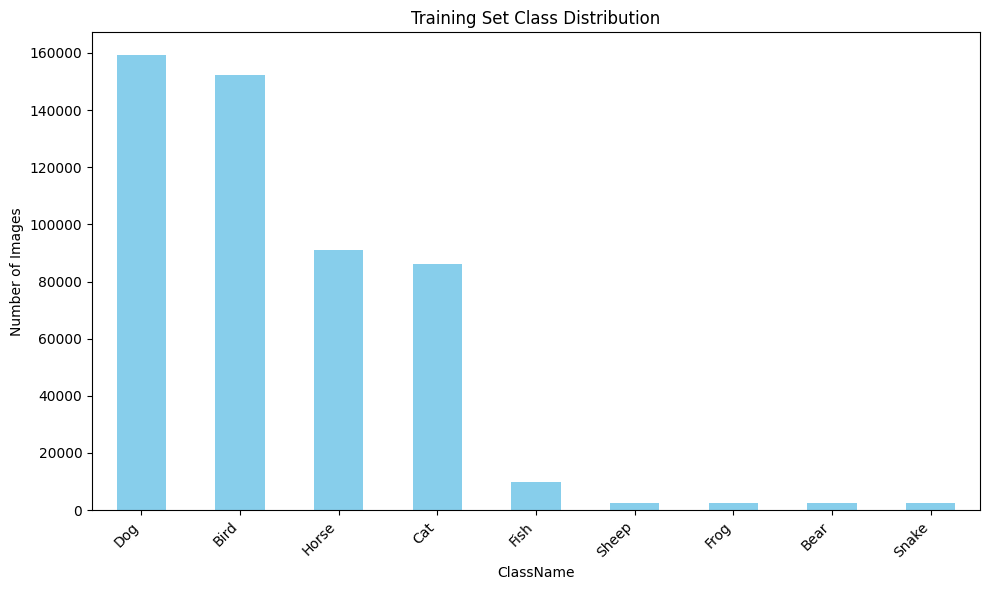

In [ ]:
class_counts = train_labels_merged.groupby("ClassName")["ImageID"].nunique().sort_values(ascending=False)
class_dist_table = class_counts.reset_index()
class_dist_table.columns = ["Class", "Number of Images"]
print(class_dist_table)

plt.figure(figsize=(10,6))
class_counts.plot(kind="bar", color="skyblue")
plt.title("Training Set Class Distribution")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

 The dataset shows a highly imbalanced distribution across the 10 selected animal classes.
 The number of images per class ranges from over 150,000 images for Dog and Bird to
 around 2,300–2,600 images for Sheep, Frog, Bear, and Snake.

 For our EDA and modeling, we will sample a balanced subset of images from each class
 (e.g., ~100-250 images per class) to ensure fair representation and reasonable
 training times.

# Filtering Usable Images

In [ ]:
tqdm.pandas()  
# Sample up to 5000 images per class (to keep runtime manageable)
sampled_df = (
    train_labels_merged.groupby('ClassName', group_keys=False)
    .apply(lambda x: x.sample(n=min(5000, len(x)), random_state=42))
)
# URL check function
def url_exists(url, timeout=2):
    try:
        r = requests.head(url, timeout=timeout)
        return r.status_code == 200
    except:
        return False
    
# Filter sampled images by valid URLs
sampled_df['valid_image'] = sampled_df['OriginalURL'].progress_apply(
    lambda x: url_exists(x) if pd.notna(x) else False
)

valid_df = sampled_df[sampled_df['valid_image']].copy()

# Pick 1500 valid URL images per class 
final_df = (
    valid_df.groupby('ClassName', group_keys=False)
    .apply(lambda x: x.sample(n=min(1500, len(x)), random_state=42))
)

print("Valid URL dataset shape:", final_df.shape)
print(final_df['ClassName'].value_counts())

# 1500 valid URLs ended up being too small, so in the next cell, 
# we include 3000 valid URLs per class. 

In [ ]:
# Second Attempt:
# Pick 3000 valid URL images per class (if possible), to increase number of valid and openable images
final_df = (
    valid_df.groupby('ClassName', group_keys=False)
    .apply(lambda x: x.sample(n=min(3000, len(x)), random_state=42))
)

print("Valid URL dataset shape:", final_df.shape)
print(final_df['ClassName'].value_counts())

Valid URL dataset shape: (24378, 14)
ClassName
Bird     3000
Cat      3000
Dog      3000
Fish     3000
Horse    3000
Sheep    2834
Frog     2306
Snake    2129
Bear     2109
Name: count, dtype: int64


<ipython-input-10-a99da7b5960b>:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(3000, len(x)), random_state=42))


In [ ]:
valid_indices = []  # Keep track of which rows succeeded

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0 Safari/537.36"
}

for idx, url in tqdm(final_df['OriginalURL'].items(), desc="Checking usable images"):
    try:
        response = requests.get(url, headers=headers, timeout=5)
        img = Image.open(BytesIO(response.content))
        valid_indices.append(idx)  # store index of successfully loaded image
    except:
        continue

# Filter final_df to only include images that successfully loaded
final_df_usable = final_df.loc[valid_indices].copy()

print(f"Number of usable images after filtering: {final_df_usable.shape[0]}")
print("Valid URL dataset shape:", final_df_usable.shape)
print(final_df_usable['ClassName'].value_counts())

Checking usable images: 24378it [27:09, 14.96it/s]

Number of usable images after filtering: 1027
Valid URL dataset shape: (1027, 14)
ClassName
Bear     302
Cat      176
Bird     171
Dog      152
Sheep     92
Frog      56
Snake     39
Fish      33
Horse      6
Name: count, dtype: int64


In [ ]:
total_before = valid_df.shape[0]
total_after = final_df_usable.shape[0]
print(f"Total sampled images: {total_before}")
print(f"Valid images after filtering: {total_after}")

Total sampled images: 31002
Valid images after filtering: 1027


 Since the dataset originally contains tens of thousands of images per class, attempting
 to load all images was not feasible due to time constraints and unreliable URLs.
 We first sampled up to 3,000 images per class to reduce processing time. Next, we
 checked that each image URL could be successfully opened and loaded and filtered out
 images that failed to load. This resulted in a usable subset of 1,027 images.

 This dataset is intended solely for EDA, including visualization of sample images,
 calculation of image size statistics, and assessment of class distributions.
 Teammates performing modeling will handle filtering and augmentation as needed to
 ensure sufficient images per class. If classes need to be deleted, they will make
 the final call.

 Note: All image counts and summary statistics reported here are based on images that
 could be successfully loaded, providing an estimate of usable data for future modeling.

# EDA

In [ ]:
# Visualize class balance of filtered data
class_balance = (
    final_df_usable['ClassName']
    .value_counts()
    .reset_index()
)

class_balance.columns = ['Class', 'Number of Usable Images']

class_balance

,Class,Number of Usable Images
0,Bear,302
1,Cat,176
2,Bird,171
3,Dog,152
4,Sheep,92
5,Frog,56
6,Snake,39
7,Fish,33
8,Horse,6


 After the filtering described earlier, classes such as Bear, Cat, Bird, and Dog retained the
 largest number of usable images, while Horse, Fish, and Snake are underrepresented, with
 Horse having only six usable images. This imbalance is due to URL inaccessibility within the
 sampled subset rather than the original dataset composition.

 This dataset is used only for exploratory data analysis to examine image quality and resolution,
 and not for model training, which is conducted separately. Teammates running models will handle data processing separately. If teammates decide to drop or change any classes, they will make that decision. They will also decide how to handle any imbalances in
 classes.

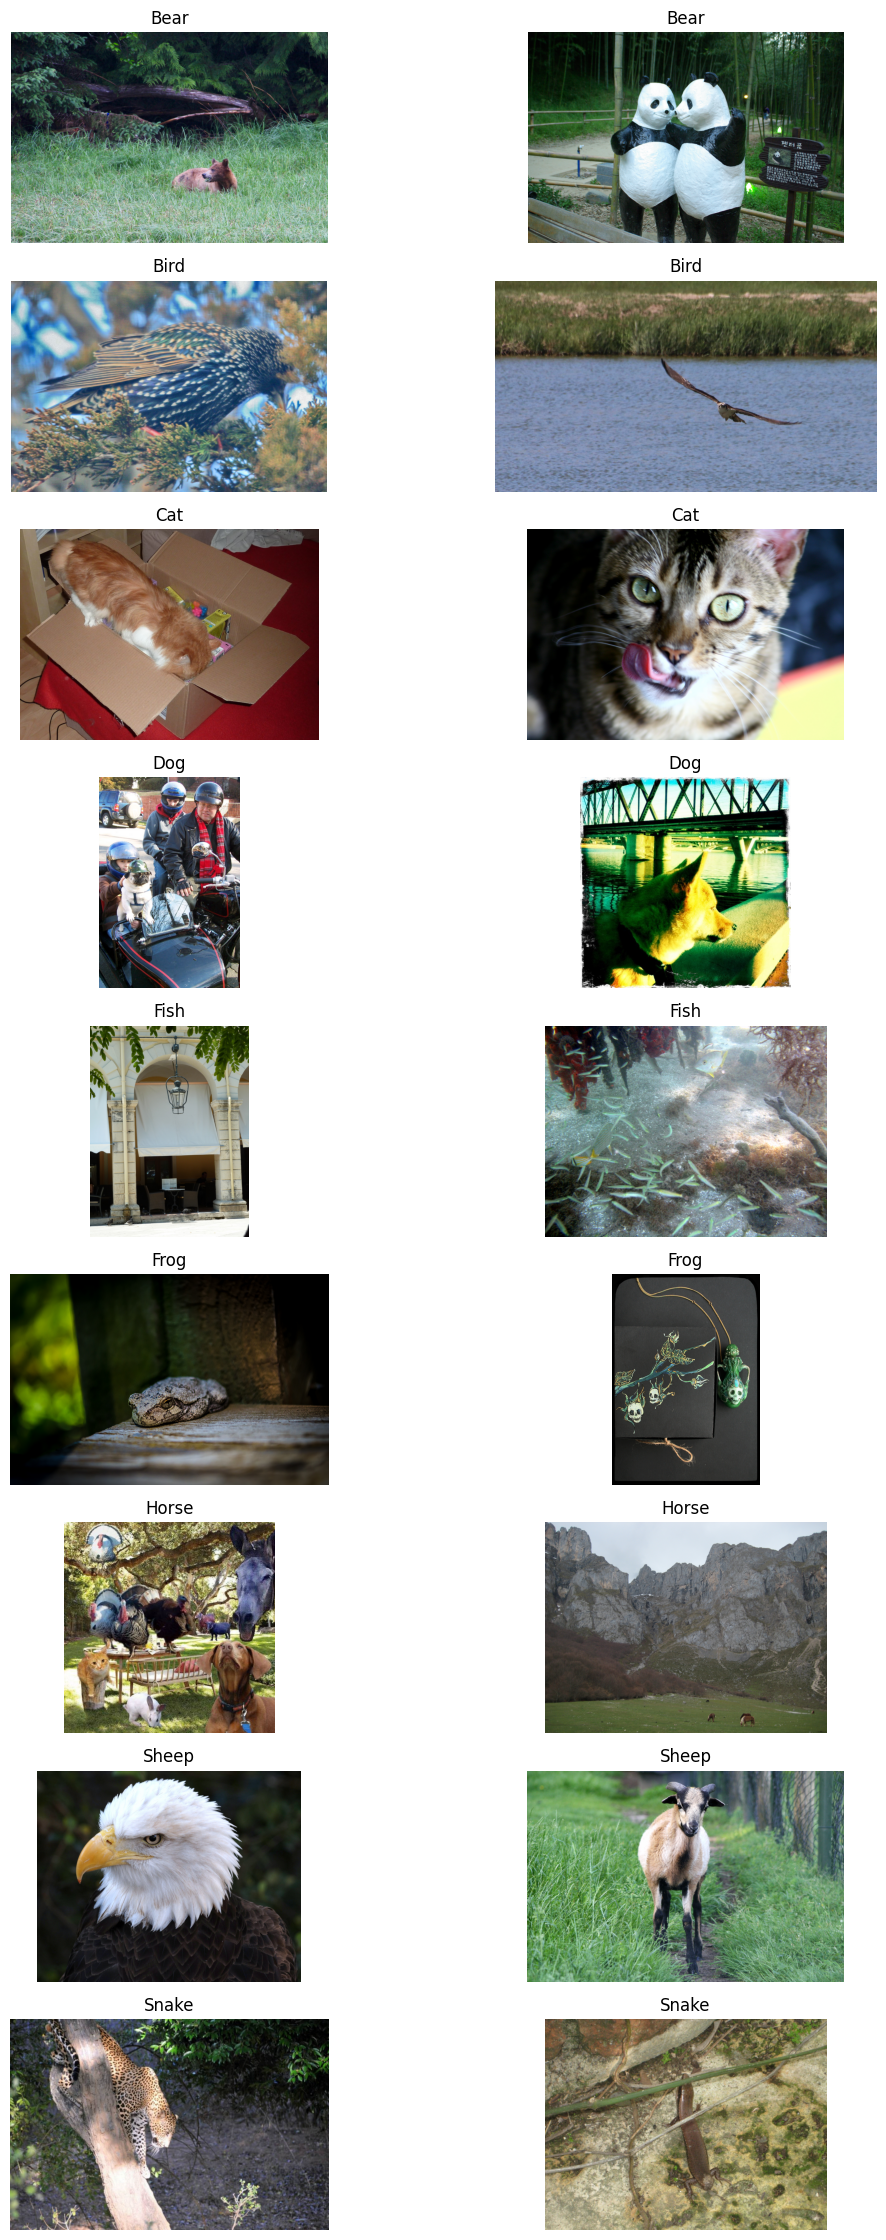

In [ ]:
# Visualize 2 images per class
classes_list = final_df_usable['ClassName'].unique()
num_classes = len(classes_list)
plt.figure(figsize=(12, num_classes * 2.5))

i = 1
for cls in classes_list:
    cls_urls = final_df_usable[final_df_usable['ClassName'] == cls]['OriginalURL'].dropna().tolist()
    
    for img_url in random.sample(cls_urls, min(2, len(cls_urls))):
        try:
            response = requests.get(img_url, headers=headers, timeout=5)
            img = Image.open(BytesIO(response.content)).convert("RGB")
            
            plt.subplot(num_classes, 2, i)
            plt.imshow(img)
            plt.title(cls)
            plt.axis('off')
            i += 1
        except Exception as e:
            print(f"Failed to load image for class {cls}: {e}")
            continue

plt.tight_layout()
plt.show()

 Looking at randomly sampled images from each class reveals lots of variability in image quality,
 composition, and context. Animals appear at different scales and orientations, ranging from
 close-up images like the second cat to distant or partially occluded subjects like the second
 horse. Backgrounds vary, including natural environments such as forests and water, as well as
 manmade settings like the second dog.

 The image quality is also inconsistent, with noticeable differences in resolution, lighting, and
 sharpness. Some images are well centered and clearly depict the target animal like the second cat,
 while others contain significant background clutter, are blurry, or include the animal as a small
 portion of the frame. In several cases, the animal is difficult to identify, such as the first snake
 image. I’m not entirely sure where the snake is present. Some labels appear incorrect, such as the
 first “sheep” that is a bald eagle, and the first fish. I doubt there’s a fish in that image.

 These observations depict the challenges of classifying real images and highlight the need for
 quality feature learning and preprocessing during the modeling process.

In [ ]:
sizes = []

tqdm.pandas(desc="Loading images for size stats")

for url in tqdm(final_df_usable['OriginalURL'], total=len(final_df_usable)):
    try:
        response = requests.get(url, timeout=5)
        response.raise_for_status()
        img = Image.open(BytesIO(response.content))
        sizes.append(img.size)  # (width, height)
    except:
        continue

100%|██████████| 1027/1027 [02:12<00:00,  7.77it/s]


In [ ]:
sizes_df = pd.DataFrame(sizes, columns=["width", "height"])
sizes_df['area'] = sizes_df['width'] * sizes_df['height']
pd.options.display.float_format = '{:,.0f}'.format  # no decimals, commas for thousands
sizes_df.describe()

,width,height,area
count,"1,027","1,027","1,027"
mean,"2,252","1,808","5,345,389"
std,"1,400","1,069","5,494,671"
min,300,150,"67,500"
25%,"1,024",838,"853,756"
50%,"2,000","1,644","3,145,728"
75%,"3,264","2,592","7,990,272"
max,"6,048","6,016","26,214,400"


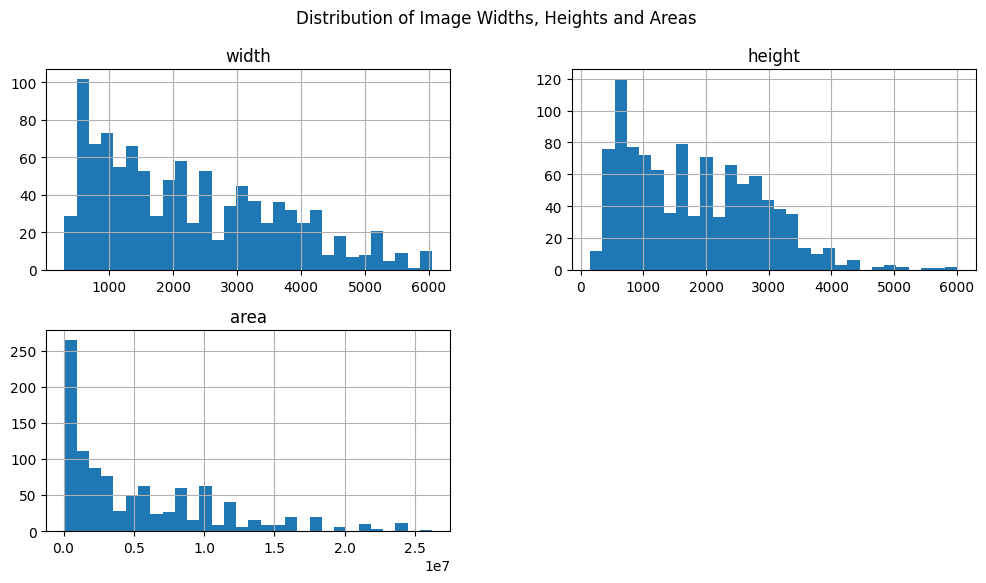

In [ ]:
sizes_df.hist(bins=30, figsize=(12,6))
plt.suptitle("Distribution of Image Widths, Heights and Areas")
plt.show()

 The images in the dataset vary widely in size. The width ranges from 300 to 6,048 pixels, with a mean
 of about 2,252 pixels, while the height ranges from 150 to 6,016 pixels, with a mean of about 1,808
 pixels. The area of the images also varies from roughly 68,000 to over 26 million pixels, with a median
 around 3.1 million pixels. Most images fall in the middle range of about 1,000–3,000 pixels in width
 and 800–2,600 pixels in height, but there are extremely small and large images. This variability suggests
 that while the dataset contains mostly reasonably sized images, there are some low-resolution images that
 might be challenging for modeling, and high-resolution images that would require resizing for
 computational efficiency. While this variability is useful to understand, images will need to be resized
 to the same dimensions before modeling so the neural network can properly process them.